In [1]:
import pandas as pd
import os

In [2]:
#loading the files
base_df = pd.read_csv('../data/data_final_with_aadt_and_vulnerability.csv')
#select only columns needed
base_subset = base_df[['id', 'avg_truck_AADT','lat', 'lon']]

scenario_results = {}
all_dfs = []
scenario_stats = []

#loop through 12 scenario files
for i in range(12):
    file_path = f'../experiment/final_delays_scenario{i}.csv'
    raw_scenario_df = pd.read_csv(file_path)

    #melt the data from wide to long format:
    #each column (seed) becomes a row
    melted_df = raw_scenario_df.melt(id_vars=['BridgeID'], var_name='Seed', value_name='Delay')

    #drops rows where Delay is missing
    melted_df = melted_df.dropna(subset=['Delay'])

    #calculate the number of unique bridges affected per seed
    bridges_per_seed = melted_df.groupby('Seed')['BridgeID'].nunique()

    #compute the average number of broken bridges in this scenario
    avg_broken_this_scenario = bridges_per_seed.mean()
    scenario_stats.append(avg_broken_this_scenario)

    #compute the averge delay per bridge across all seeds
    scenario_avg = melted_df.groupby('BridgeID')['Delay'].mean().reset_index()

    #merge with base data (AADT and location info)
    merged_df = pd.merge(
        scenario_avg,
        base_subset,
        left_on='BridgeID',
        right_on='id'
    ).copy()

    #rename columns and drop duplicate ID column
    merged_df = merged_df.rename(columns={'Delay': 'Total_Delay'}).drop(columns=['BridgeID'])

    #compute raw impact: delay multiplied by truck traffic
    merged_df['impact_raw'] = merged_df['Total_Delay'] * merged_df['avg_truck_AADT']
    merged_df['scenario_id'] = i

    all_dfs.append(merged_df)

#combine all scenario data to calculate global min and max
combined_data = pd.concat(all_dfs)
global_min = combined_data['impact_raw'].min()
global_max = combined_data['impact_raw'].max()

#scale impact values between 0 and 1 (min-max scaling)
for i in range(len(all_dfs)):
    all_dfs[i].loc[:, 'impact_scaled'] = (all_dfs[i]['impact_raw'] - global_min) / (global_max - global_min)

    scenario_results[f'scenario_{i}'] = all_dfs[i]

    #create seperate variables for each scenario (df_0, df_1, etc.)
    globals()[f'df_{i}'] = all_dfs[i]


In [3]:
#total amount of bridges
count_bridges = len(base_df[base_df['model_type'] == 'bridge'])

print(f"Amount bridges: {count_bridges}")

Amount bridges: 1434


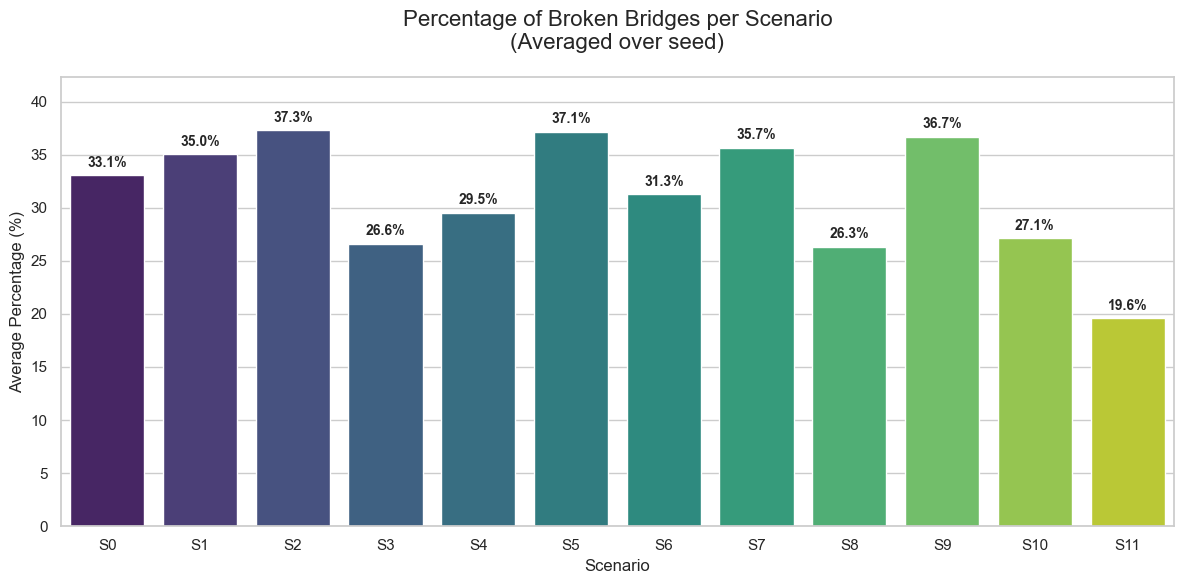

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

#calculate percentages based on the average broken bridges per seed (from scenario_stats)
#'count_bridges' is the total number of bridges in base_df
percentages = [(avg_count / count_bridges) * 100 for avg_count in scenario_stats]
labels = [f"S{i}" for i in range(len(scenario_stats))]

plot_df = pd.DataFrame({
    'Scenario': labels,
    'Percentage': percentages
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.barplot(x='Scenario', y='Percentage', data=plot_df, palette='viridis', hue='Scenario', legend=False)


plt.title('Percentage of Broken Bridges per Scenario\n(Averaged over seed)', fontsize=16, pad=20)
plt.ylabel('Average Percentage (%)', fontsize=12)
plt.xlabel('Scenario', fontsize=12)

plt.ylim(0, max(percentages) + 5)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10,
                fontweight='bold')

plt.tight_layout()

plt.savefig('../img/average_broken_bridges_per_seed.png', dpi=300, bbox_inches='tight')

plt.show()

In [7]:
combined_df = pd.concat(all_dfs)

avg_impact_per_bridge = combined_df.groupby('id').agg({
    'impact_scaled': 'mean',
    'impact_raw': 'mean',
    'avg_truck_AADT': 'first',
    'lat': 'first',
    'lon': 'first',
    'scenario_id': lambda x: list(x)
}).rename(columns={'scenario_id': 'scenarios_found'})

#compute average impact per bridge across all scenarios
avg_impact_per_bridge['occurrence_count'] = avg_impact_per_bridge['scenarios_found'].apply(len)

#count how many scenarios each bridge appears in
avg_impact_per_bridge = avg_impact_per_bridge.sort_values(by='impact_scaled', ascending=False)

avg_impact_per_bridge[['impact_scaled', 'occurrence_count', 'scenarios_found']].head(20)

,impact_scaled,occurrence_count,scenarios_found
id,,,
100083,0.879217,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100047,0.829622,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100051,0.783681,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
101484,0.647530,11,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
100031,0.442117,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100075,0.422411,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100049,0.401661,11,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
100043,0.397597,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100059,0.371042,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"


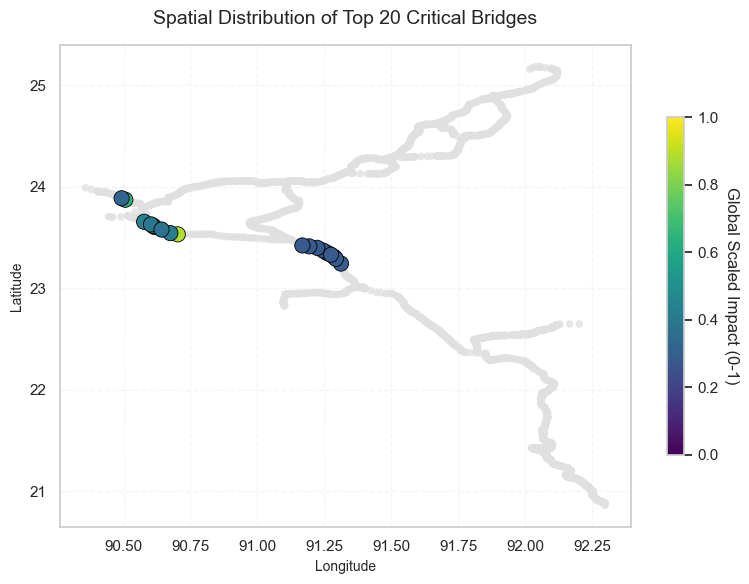

In [8]:
top_20_df = avg_impact_per_bridge.head(20).copy().reset_index()

fig, ax = plt.subplots(figsize=(8, 6))

#layer1
ax.scatter(base_df['lon'], base_df['lat'],
           color='#e0e0e0',
           s=30,
           alpha=0.8,
           edgecolor='none',
           zorder=1)

#layer2 most critical bridges
sc = ax.scatter(top_20_df['lon'], top_20_df['lat'],
                c=top_20_df['impact_scaled'],
                cmap='viridis',
                s=120,
                alpha=1.0,
                edgecolor='black',
                linewidth=0.6,
                zorder=2)

ax.set_title("Spatial Distribution of Top 20 Critical Bridges", fontsize=14, pad=15)
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)

ax.grid(True, linestyle='--', alpha=0.2)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('Global Scaled Impact (0-1)', rotation=270, labelpad=15)
sc.set_clim(0, 1)

plt.tight_layout()

plt.savefig('../img/broken_bridges_map.png', dpi=300, bbox_inches='tight')

plt.show()